# 03 — Fairness and calibration audit

Does the missed-visit model treat groups differently? For each group we compare: base rate, mean prediction, AUC,
**selection rate at worklist capacity** (who gets on the list), **false-negative rate at capacity** (who is missed by the list),
and calibration error. Groups: sex, age band, facility, distance band, and **region** — which is *not* a feature and appears only here.

Design principle (see `docs/responsible_ai.md`): a high score adds support; it never removes anyone. So the harm to watch for is
*under-selection* of a group that misses often (they don't get help), and *over-selection* of a group that doesn't (wasted calls, stigma).

In [1]:
import sys, warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve(); ROOT = ROOT if (ROOT / "D_Clinic_Backend").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "D_Clinic_Backend"))
from app.db import engine
from ml.features import load_tables_from_db, build_feature_table, FEATURES
from ml.train import (make_splits, fit_all, evaluate, precision_at_capacity, calibration_table, fairness_table,
                      explain_rows, oracle_ceiling, MODEL_FEATURES, CAPACITY_SHARE)
from ml.cold_start import add_pooled_feature
plt.rcParams["figure.figsize"] = (9, 3.5)
AS_OF = pd.Timestamp("2026-09-26")
tables = load_tables_from_db(engine)
ft = build_feature_table(tables, AS_OF)
splits = make_splits(ft)
res = fit_all(splits)
te, p = res["frames"]["test"], res["preds"]["test"][res["chosen"]]
print("chosen:", res["chosen"], {k: len(v) for k, v in splits.items()})

chosen: logistic {'train': 13422, 'valid': 977, 'test': 2028}


## 1. Fairness tables (test set)

In [2]:
for col in ["gender", "age_band", "distance_band", "region", "facility_id"]:
    print(f"\n### by {col}")
    display(fairness_table(te, p, col))


### by gender


,gender,n,base_rate,mean_pred,auc,selection_rate,fnr_at_capacity,ece
0,female,1151,0.299,0.296,0.644,0.295,0.558,0.027
1,male,877,0.290,0.312,0.656,0.348,0.488,0.029



### by age_band


,age_band,n,base_rate,mean_pred,auc,selection_rate,fnr_at_capacity,ece
0,40-49,479,0.269,0.288,0.642,0.276,0.651,0.036
1,50-59,680,0.301,0.299,0.633,0.306,0.522,0.020
2,60-69,456,0.292,0.297,0.620,0.307,0.556,0.035
3,70+,219,0.260,0.306,0.662,0.311,0.509,0.072
4,<40,194,0.381,0.364,0.735,0.495,0.297,0.064



### by distance_band


,distance_band,n,base_rate,mean_pred,auc,selection_rate,fnr_at_capacity,ece
0,far,286,0.360,0.400,0.646,0.601,0.301,0.043
1,mid,785,0.280,0.312,0.671,0.348,0.455,0.033
2,near,957,0.287,0.266,0.632,0.208,0.673,0.021



### by region


,region,n,base_rate,mean_pred,auc,selection_rate,fnr_at_capacity,ece
0,Lagos,936,0.286,0.279,0.641,0.299,0.556,0.022
1,Ogun,915,0.314,0.325,0.649,0.330,0.523,0.013
2,Oyo,177,0.243,0.314,0.691,0.350,0.395,0.072



### by facility_id


,facility_id,n,base_rate,mean_pred,auc,selection_rate,fnr_at_capacity,ece
0,0540ebea-e3f5-484b-9c62-2f6f575c73a9,239,0.385,0.386,0.611,0.326,0.576,0.061
1,356b91c4-74fa-4ed5-8a5c-6a6f740905ce,410,0.320,0.333,0.684,0.320,0.504,0.026
2,6efab8db-f0a2-4fd3-acb9-d94610c2b4a1,611,0.303,0.305,0.619,0.311,0.541,0.033
3,8826d916-cdfb-41c6-81ff-91a761565a70,433,0.249,0.246,0.634,0.319,0.519,0.017
4,fc85e6da-3f50-4390-b347-461412f7d6c3,335,0.245,0.276,0.645,0.319,0.500,0.036


## 2. Selection rate vs base rate

If the list is fair in the sense of *equal opportunity for support*, selection should track how often each group actually misses.

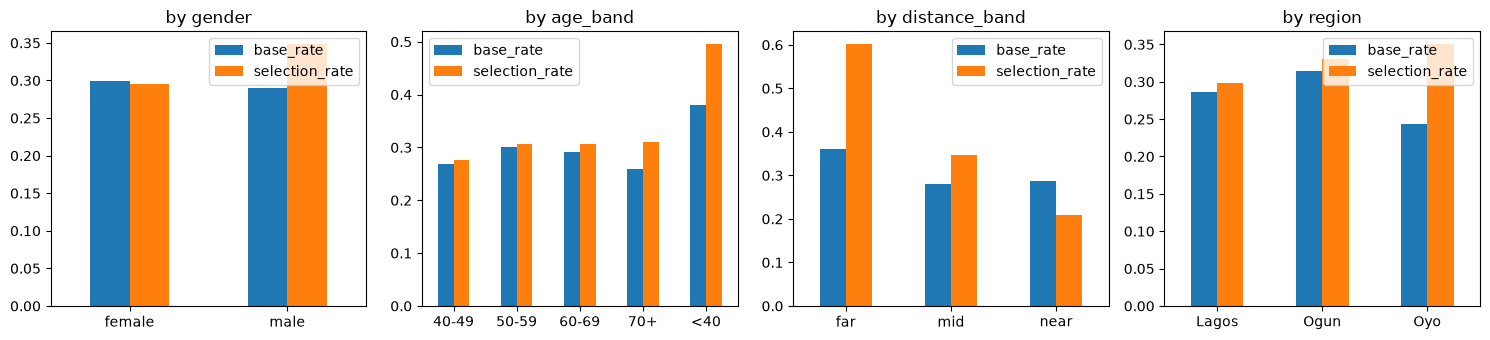

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, ["gender", "age_band", "distance_band", "region"]):
    t = fairness_table(te, p, col).set_index(col)
    t[["base_rate", "selection_rate"]].plot.bar(ax=ax, rot=0, title=f"by {col}"); ax.set_xlabel("")
plt.tight_layout()

## 3. Calibration within groups

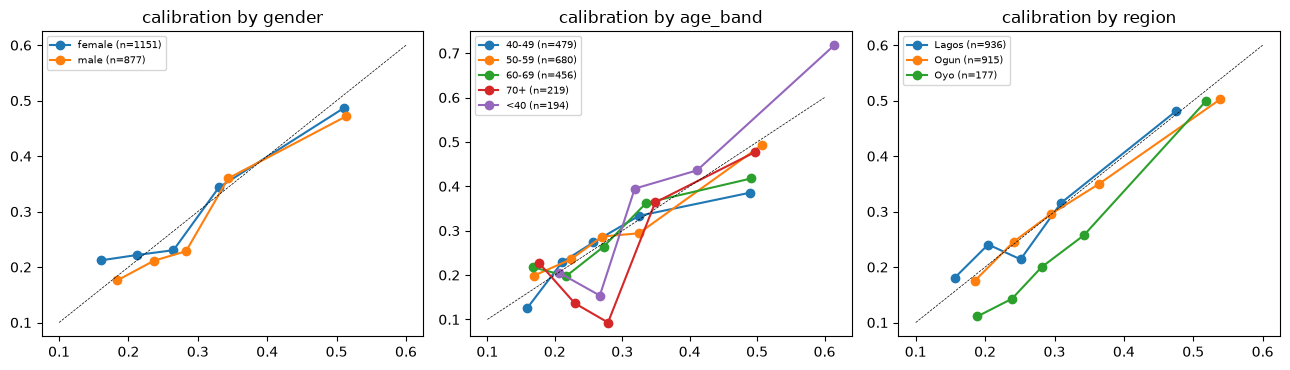

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col in zip(axes, ["gender", "age_band", "region"]):
    for g, d in te.assign(p=p).groupby(col):
        ct = calibration_table(d.missed.astype(int).values, d.p.values, 5)
        ax.plot(ct.predicted, ct.observed, marker="o", label=f"{g} (n={len(d)})")
    ax.plot([0.1, 0.6], [0.1, 0.6], "k--", lw=.5); ax.set_title(f"calibration by {col}"); ax.legend(fontsize=7)
plt.tight_layout()

## 4. The region gap, decomposed

The generator gives region **no causal effect**, yet raw miss rates differ by region. Distance band is the mediator: some regions have more
patients living far from their facility. Within a distance band, the regional differences shrink to noise. This is why distance is a feature
(actionable: travel support, closer facility, longer refills) and region is not (a proxy for access that would encode the disparity).

In [5]:
aud = te.assign(p=p, missed=te.missed.astype(int))
display(aud.pivot_table(index="distance_band", columns="region", values="missed", aggfunc="mean").round(3).reindex(["near", "mid", "far"]))
display(aud.pivot_table(index="distance_band", columns="region", values="p", aggfunc="mean").round(3).reindex(["near", "mid", "far"]))
pd.crosstab(aud.region, aud.distance_band, normalize="index").round(3)[["near", "mid", "far"]]

region,Lagos,Ogun,Oyo
distance_band,,,
near,0.289,0.281,0.333
mid,0.257,0.318,0.217
far,0.373,0.413,0.224


region,Lagos,Ogun,Oyo
distance_band,,,
near,0.246,0.289,0.254
mid,0.291,0.332,0.319
far,0.396,0.428,0.346


distance_band,near,mid,far
region,,,
Lagos,0.517,0.374,0.109
Ogun,0.478,0.385,0.138
Oyo,0.203,0.469,0.328


## 5. Uncertainty for small groups

Bootstrap the selection-rate gap (selection − base rate) for the smallest region, and compare that region's miss rate in the small test sample with its rate across the whole labelled cohort.

In [6]:
rng = np.random.default_rng(0)
small = fairness_table(te, p, "region").set_index("region").n.idxmin()
def gap(sample):
    t = fairness_table(sample, sample.p.values, "region").set_index("region")
    return t.loc[small, "selection_rate"] - t.loc[small, "base_rate"]
aud2 = te.assign(p=p)
boots = [gap(aud2.sample(frac=1, replace=True, random_state=int(s))) for s in rng.integers(0, 1e6, 200)]
lo, hi = np.percentile(boots, 2.5), np.percentile(boots, 97.5)
print(f"{small}: selection − base rate = {gap(aud2):.3f}; 95% bootstrap interval [{lo:.3f}, {hi:.3f}]")
from ml.features import labelled
allrows = labelled(ft).frame
cmp = pd.DataFrame({"test sample": te.groupby("region").missed.mean(), "whole labelled cohort": allrows.groupby("region").missed.mean(),
                    "n test": te.groupby("region").size(), "n cohort": allrows.groupby("region").size()}).round(3)
display(cmp)
direction = "over-selected (more support offered than its miss rate alone would warrant)" if gap(aud2) > 0 else "under-selected (less support than its miss rate warrants)"
print(f"Reading: {small} is {direction}. Interval {'excludes' if lo > 0 or hi < 0 else 'includes'} zero.")

Oyo: selection − base rate = 0.107; 95% bootstrap interval [0.028, 0.192]


,test sample,whole labelled cohort,n test,n cohort
region,,,,
Lagos,0.286,0.259,936,17247
Ogun,0.314,0.303,915,16000
Oyo,0.243,0.305,177,3077


Reading: Oyo is over-selected (more support offered than its miss rate alone would warrant). Interval excludes zero.


## Findings and decisions

- **Sex.** Selection tracks base rate for women (0.30 vs 0.30). Men are selected somewhat more than their base rate (≈0.35 vs 0.29): `male` is a small positive feature in the generator and the model. Their false-negative rate at capacity is correspondingly *lower*, so men are not disadvantaged; women's FNR (0.56) is the number to watch, and it is in line with the overall rate.
- **Age.** Under-40s miss most often (0.38) and are selected most (≈0.50); their FNR at capacity is the lowest (0.30). Over-70s are selected at roughly their base rate but with the largest calibration error (ECE 0.07, n = 219) — a small-group effect to monitor, not a systematic under-selection.
- **Distance.** Patients living far are selected more *because* they miss more. That is the intended behaviour: the list exists to offer them support.
- **Region.** The raw gap in miss rate is explained by distance composition (§4); within distance bands the differences shrink. Region stays out of the model.
- **Smallest region (§5).** In this test split the smallest region is *over*-selected by roughly 0.1, and the bootstrap interval excludes zero. Two facts frame this: the generator gives region no causal effect, and the region's miss rate over the whole cohort is in line with the others while its small test sample happens to be low — so the gap reflects the composition of a ~180-row sample, not a regional mechanism. Under the design principle (a score only *adds* support) over-selection is the less harmful direction, so no threshold change is made; the gap is logged as a **monitoring item** and must be re-checked on every retrain. Had the direction been under-selection of a group that misses often, the decision would be a per-facility threshold adjustment before promotion.
- **Facility.** Differences reflect real facility-level miss rates; the capacity metric is computed *within* facility, so no facility crowds out another.
- **Promotion gate (Step 9).** Retraining must regenerate these tables and fail promotion if any group's false-negative rate at capacity exceeds the overall rate by more than 0.10, or if any group with n ≥ 300 is under-selected relative to its base rate by more than 0.05.